# **Sintetizadores**

#### <span style="color: magenta">**Sintetizador**</span> = generador de señal + envolvente ADSR

"Nuestro" concepto de sintetizador (igual que en SuperCollider):

- Es un **generador** que tiene una *señal* de audio controlada por una envolvente *ADSR*

- Se activa con mensaje *start*: dispara el generador

    - envolvente *AD* + mantenimiento en sustain *S*

- Se para con mensaje *release*: 

    - Envolvente release *R*

Como todos nuestros generadores tiene el mensaje **next** que devuelve señal

- Si no se ha activado devuelve 0 (silencio)

- Si está activo devuelve $(señal*adsr)$

## Controlando el generador FM

La generación FM "puede" producir timbres muy ricos, pero también muy caóticos:

- Para obtener timbres "afinables" y armónicos es crítico el **ratio $\frac{fm}{fc}$**

- Los timbres más *musicales* se obtienen con ratios enteros 

Parametrizamos el sintetizador con *fc,ratio* y *beta* y

- Obtenemos la moduladora como $fm=ratio*fc$

Propiedades de este sintetizador:

- Configurable la nota, la envolvente, el timbre... 

- Es monofónico (solo produce una nota simultánea)

- Se crea, genera la nota pedida y desaparece

In [1]:
%%writefile synthFM.py

import numpy as np   
import matplotlib.pyplot as plt
from consts import *
from tkinter import *
from adsr import *
from oscFM import *

class SynthFM:
    def __init__(self,
                fc=110,amp=1.0,ratio=0.5, beta=5.0,   # parámetros del generador FM
                attack=0.01,decay=0.02, sustain=0.3,release=1.0): # parámetros del ADSR        
        self.fc = fc
        self.amp =  amp
        self.ratio = ratio
        self.fm = self.ratio*self.fc # fm en función de fc y ratio
        self.beta = beta
        
        self.signal = OscFM(self.fc,amp=self.amp,fm=self.fm,beta=self.beta) # generador
        self.adsr = ADSR(attack,decay,sustain,release)  # envolvente adsr

        # se dispara automáticamente
        self.state = 'on' # activo
        self.adsr.start() # adsr activa

    def start(self):
        self.adsr.start()

    # siguiente chunk del generador
    def next(self): 
        out = self.signal.next()*self.adsr.next()
        if self.adsr.state=='off': # cuando acaba el adsr por completo (incluido el release)
            self.state = 'off'     # el sinte tb acaba de producir señal
        return out     
    
    # el noteOff del sinte activa el release del ADSR
    def noteOff(self):
        #print('release')
        self.adsr.release()

    def setAmp(self,val): 
        self.amp = val 

    def setFm(self,val): 
        self.fm = val  

    def setBeta(self,val): 
        self.beta = val


Writing synthFM.py


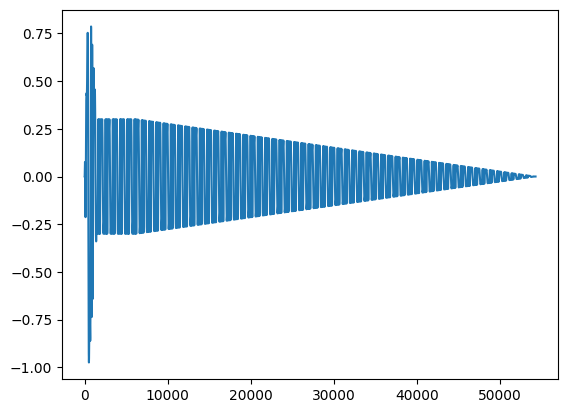

In [1]:
from synthFM import *
import sounddevice as sd


stream = sd.OutputStream(samplerate=SRATE, channels=1, blocksize=CHUNK)
stream.start()

synth = SynthFM()

tot = np.zeros(1)
# generamos 30 chunks
for n in range(6): 
    sig = synth.next()              
    stream.write(np.float32(sig))
    tot = np.concatenate((tot,sig))

#plt.plot(tot)

## apagamos nota generamos hasta el final del release
synth.noteOff()
while synth.state!='off':        
    sig = synth.next()
    stream.write(np.float32(sig))
    tot = np.concatenate((tot,sig))
    
stream.close()
plt.plot(tot)
